## Import libs

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset
import seaborn as sns


from models.unfair_lr.models import UnfairLogisticRegression
from models.unfair_lr.learning import train_loop
from util.evaluation import *
from util.load_data import load_data

/Users/lffpl/Projects/falsb/env/falsb/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Preliminaries

In [2]:
batch_size = 64
epochs = 100
lr = 0.001

In [3]:
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'balanced-arrhythmia'

In [5]:
x, y, a = load_data(data_name)
raw_data = (x, y, a)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
adim = a.shape[1]
zdim = 8

In [7]:
print(xdim, ydim, adim)
print(len(x))

278 1 1
474


## Result file

In [8]:
header = "model_name", "cv_seed", "clas_acc", "dp", "deqodds", "deqopp", "trade_dp", "trade_deqodds", "trade_deqopp", "TN_a0", "FP_a0", "FN_a0", "TP_a0", "TN_a1", "FP_a1", "FN_a1", "TP_a1"
results = []

## Testing

In [9]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

2026-01-04 11:30:30.597687: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-04 11:30:30.625187: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch | Class Loss | Class Acc
> 1 | 0.7398478388786316 | 0.528125
> 2 | 0.7111493349075317 | 0.528125
> 3 | 0.7003777027130127 | 0.528125
> 4 | 0.6963582634925842 | 0.528125
> 5 | 0.6948371529579163 | 0.528125
> 6 | 0.6938628554344177 | 0.53125


2026-01-04 11:30:30.677619: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-04 11:30:30.782724: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 7 | 0.6931452751159668 | 0.53125
> 8 | 0.6925557851791382 | 0.53125
> 9 | 0.6920521259307861 | 0.53125
> 10 | 0.6916106939315796 | 0.53125
> 11 | 0.6912170648574829 | 0.53125
> 12 | 0.6908613443374634 | 0.53125
> 13 | 0.6905364990234375 | 0.53125
> 14 | 0.6902375221252441 | 0.53125
> 15 | 0.6899603605270386 | 0.53125
> 16 | 0.6897019743919373 | 0.53125
> 17 | 0.6894599795341492 | 0.53125
> 18 | 0.6892324090003967 | 0.53125
> 19 | 0.6890175342559814 | 0.53125
> 20 | 0.6888140439987183 | 0.53125
> 21 | 0.6886208057403564 | 0.53125
> 22 | 0.68843674659729 | 0.53125


2026-01-04 11:30:31.004662: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

> 71 | 0.6838524341583252 | 0.540625
> 72 | 0.6837981939315796 | 0.540625
> 73 | 0.6837447881698608 | 0.540625
> 74 | 0.6836920380592346 | 0.540625
> 75 | 0.6836400032043457 | 0.540625
> 76 | 0.6835887432098389 | 0.540625
> 77 | 0.6835380792617798 | 0.540625
> 78 | 0.6834880709648132 | 0.540625
> 79 | 0.6834388375282288 | 0.540625
> 80 | 0.6833901405334473 | 0.54375
> 81 | 0.6833420395851135 | 0.54375
> 82 | 0.6832945346832275 | 0.54375
> 83 | 0.6832476854324341 | 0.54375
> 84 | 0.6832013130187988 | 0.546875
> 85 | 0.6831555366516113 | 0.546875
> 86 | 0.6831103563308716 | 0.546875
> 87 | 0.68306565284729 | 0.546875
> 88 | 0.6830214262008667 | 0.546875
> 89 | 0.6829777956008911 | 0.546875
> 90 | 0.6829346418380737 | 0.546875
> 91 | 0.6828919649124146 | 0.546875
> 92 | 0.6828497648239136 | 0.546875
> 93 | 0.682807981967926 | 0.546875
> 94 | 0.6827666759490967 | 0.546875
> 95 | 0.6827257871627808 | 0.546875
> 96 | 0.682685375213623 | 0.546875
> 97 | 0.6826454401016235 | 0.546875
> 98 | 0.

2026-01-04 11:30:33.946528: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 27 | 0.6868632435798645 | 0.6125
> 28 | 0.6867796182632446 | 0.6125
> 29 | 0.6866983771324158 | 0.6125
> 30 | 0.6866195797920227 | 0.6125
> 31 | 0.686542809009552 | 0.61875
> 32 | 0.686468243598938 | 0.621875
> 33 | 0.6863956451416016 | 0.61875
> 34 | 0.686324954032898 | 0.61875
> 35 | 0.6862560510635376 | 0.61875
> 36 | 0.6861889362335205 | 0.61875
> 37 | 0.6861233711242676 | 0.61875
> 38 | 0.6860593557357788 | 0.61875
> 39 | 0.685996949672699 | 0.621875
> 40 | 0.6859359741210938 | 0.621875
> 41 | 0.6858763694763184 | 0.628125
> 42 | 0.6858180165290833 | 0.63125
> 43 | 0.6857609748840332 | 0.634375
> 44 | 0.6857051849365234 | 0.634375
> 45 | 0.6856505274772644 | 0.6375
> 46 | 0.6855970025062561 | 0.640625
> 47 | 0.6855446100234985 | 0.640625
> 48 | 0.6854931116104126 | 0.6375
> 49 | 0.6854426860809326 | 0.6375
> 50 | 0.6853932738304138 | 0.640625
> 51 | 0.6853448152542114 | 0.64375
> 52 | 0.6852971315383911 | 0.64375
> 53 | 0.6852504014968872 | 0.64375
> 54 | 0.6852045059204102 | 0.

2026-01-04 11:30:37.532602: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 58 | 0.6752397418022156 | 0.534375
> 59 | 0.6751881837844849 | 0.534375
> 60 | 0.6751376390457153 | 0.534375
> 61 | 0.6750878691673279 | 0.534375
> 62 | 0.6750388741493225 | 0.534375
> 63 | 0.674990713596344 | 0.534375
> 64 | 0.6749432682991028 | 0.534375
> 65 | 0.6748966574668884 | 0.534375
> 66 | 0.6748507022857666 | 0.534375
> 67 | 0.6748055219650269 | 0.534375
> 68 | 0.6747609376907349 | 0.534375
> 69 | 0.6747170686721802 | 0.534375
> 70 | 0.6746737360954285 | 0.534375
> 71 | 0.6746311187744141 | 0.534375
> 72 | 0.6745890378952026 | 0.534375
> 73 | 0.674547553062439 | 0.534375
> 74 | 0.6745067834854126 | 0.534375
> 75 | 0.6744664311408997 | 0.534375
> 76 | 0.6744266748428345 | 0.534375
> 77 | 0.6743874549865723 | 0.534375
> 78 | 0.6743487119674683 | 0.534375
> 79 | 0.6743104457855225 | 0.534375
> 80 | 0.6742727160453796 | 0.534375
> 81 | 0.6742354035377502 | 0.534375
> 82 | 0.6741986274719238 | 0.534375
> 83 | 0.6741622686386108 | 0.534375
> 84 | 0.6741263270378113 | 0.534375
> 8

<Axes: >

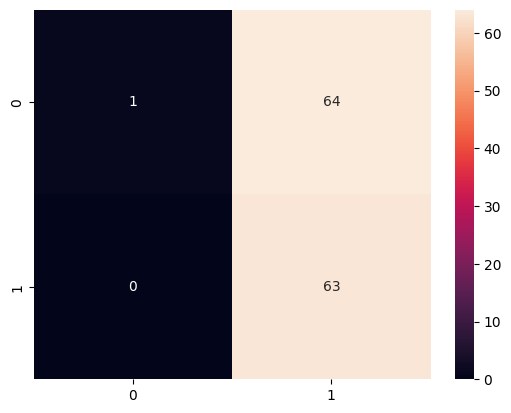

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

In [11]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    opt = Adam(learning_rate=lr)

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs, opt)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

    del(opt)

> Epoch | Class Loss | Class Acc
> 1 | 0.7398478388786316 | 0.528125
> 2 | 0.7005855441093445 | 0.528125
> 3 | 0.691325306892395 | 0.5375
> 4 | 0.6907918453216553 | 0.51875
> 5 | 0.6863954067230225 | 0.503125
> 6 | 0.6810085773468018 | 0.61875
> 7 | 0.6780937910079956 | 0.590625
> 8 | 0.6758916974067688 | 0.55625
> 9 | 0.6722034215927124 | 0.55625
> 10 | 0.6675903797149658 | 0.584375
> 11 | 0.6633014678955078 | 0.65
> 12 | 0.659530758857727 | 0.7
> 13 | 0.6560515761375427 | 0.70625
> 14 | 0.6527783274650574 | 0.703125


2026-01-04 11:30:44.521834: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 15 | 0.6495541334152222 | 0.703125
> 16 | 0.6461923122406006 | 0.70625
> 17 | 0.6427098512649536 | 0.715625
> 18 | 0.6392548084259033 | 0.71875
> 19 | 0.6359223127365112 | 0.728125
> 20 | 0.6327182054519653 | 0.74375
> 21 | 0.6295982599258423 | 0.75
> 22 | 0.626509428024292 | 0.75
> 23 | 0.623430609703064 | 0.75
> 24 | 0.6203806400299072 | 0.75625
> 25 | 0.6173887252807617 | 0.765625
> 26 | 0.6144673824310303 | 0.775
> 27 | 0.611609935760498 | 0.78125
> 28 | 0.6088018417358398 | 0.78125
> 29 | 0.6060347557067871 | 0.78125
> 30 | 0.6033104658126831 | 0.78125
> 31 | 0.6006351709365845 | 0.784375
> 32 | 0.5980120301246643 | 0.7875
> 33 | 0.5954391956329346 | 0.7875
> 34 | 0.5929124355316162 | 0.790625
> 35 | 0.5904290080070496 | 0.79375
> 36 | 0.5879884958267212 | 0.8
> 37 | 0.5855916738510132 | 0.803125
> 38 | 0.5832383632659912 | 0.809375
> 39 | 0.5809273719787598 | 0.80625
> 40 | 0.5786569118499756 | 0.80625
> 41 | 0.5764257311820984 | 0.809375
> 42 | 0.5742329955101013 | 0.809375
> 

<Axes: >

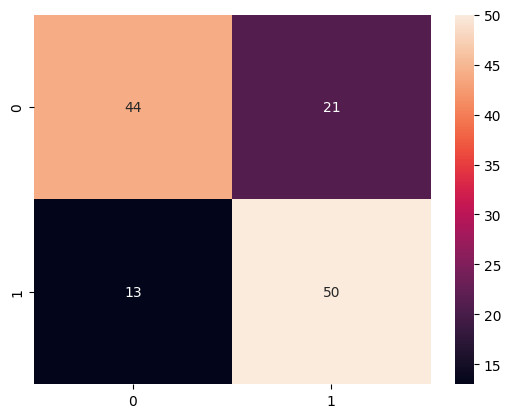

In [12]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [13]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,UnfairLR-decay,13,0.484375,0.966102,0.975000,1.000000,0.645244,0.647216,0.652632,0.0,28.0,0.0,41.0,2.0,38.0,0.0,19.0
1,UnfairLR-decay,29,0.601562,0.672269,0.717264,0.762857,0.634953,0.654338,0.672676,5.0,22.0,6.0,44.0,19.0,18.0,5.0,9.0
2,UnfairLR-decay,42,0.414062,0.983333,0.981481,1.000000,0.582743,0.582418,0.585635,1.0,26.0,0.0,33.0,0.0,49.0,0.0,19.0
3,UnfairLR-decay,55,0.585938,0.627077,0.658792,0.602273,0.605810,0.620233,0.593993,14.0,8.0,21.0,23.0,35.0,3.0,21.0,3.0
4,UnfairLR-decay,73,0.500000,0.984375,0.983871,1.000000,0.663158,0.663043,0.666667,1.0,30.0,0.0,33.0,0.0,34.0,0.0,30.0
5,UnfairLR,13,0.687500,0.563744,0.658743,0.781772,0.619502,0.672814,0.731611,8.0,20.0,4.0,37.0,30.0,10.0,6.0,13.0
6,UnfairLR,29,0.687500,0.462694,0.545547,0.568571,0.553128,0.608352,0.622405,9.0,18.0,7.0,43.0,30.0,7.0,8.0,6.0
7,UnfairLR,42,0.687500,0.649020,0.741475,0.752791,0.667706,0.713468,0.718666,12.0,15.0,4.0,29.0,35.0,14.0,7.0,12.0
8,UnfairLR,55,0.726562,0.543011,0.645534,0.621212,0.621518,0.683656,0.669770,13.0,9.0,9.0,35.0,35.0,3.0,14.0,10.0
9,UnfairLR,73,0.734375,0.578125,0.599782,0.630303,0.646949,0.660289,0.678371,14.0,17.0,1.0,32.0,30.0,4.0,12.0,18.0


In [14]:
result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')